# Battery SOH & RUL Predictive Modelling

## NASA Li-ion Battery Prognostics

This notebook develops predictive models for battery State of Health (SOH) and Remaining Useful Life (RUL) using the NASA lithium-ion battery ageing dataset.

### Objectives

1. Load discharge-level battery degradation data using the validated NASA data pipeline.
2. Engineer causal degradation and rolling-trend features.
3. Develop SOH prediction models using chronological validation.
4. Develop RUL prediction models without direct cycle-to-RUL target leakage.
5. Compare linear and nonlinear machine-learning approaches.
6. Analyse prediction bias and model behaviour near End of Life (EOL).
7. Evaluate cross-battery generalization using multiple NASA batteries.

### Modelling principles

- `cycle` represents the sequential **discharge cycle**, not the raw NASA experimental event index.
- `record_index` is retained only for source-data traceability.
- Future information is never used to construct predictive features.
- Train/test splitting is chronological; observations are never randomly shuffled.
- The cycle-only RUL identity relationship is not treated as a predictive ML model.
- EOL is defined as the first measured discharge cycle at or below 80% SOH.
- RUL is expressed as the number of remaining discharge cycles until the EOL threshold.

In [1]:
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

warnings.filterwarnings("ignore")

# ---------------------------------------------------------
# Project paths
# ---------------------------------------------------------

PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data" / "raw"
SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from nasa_loader import load_nasa_battery
from battery_features import (
    add_soh_features,
    add_degradation_features,
)

print(f"Project root: {PROJECT_ROOT}")
print(f"Data directory: {DATA_DIR}")
print(f"Source directory: {SRC_DIR}")

Project root: C:\Users\Drago\Battery-Analytics-Portfolio
Data directory: C:\Users\Drago\Battery-Analytics-Portfolio\data\raw
Source directory: C:\Users\Drago\Battery-Analytics-Portfolio\src


In [2]:
# Load B0005 and B0006

b0005 = load_nasa_battery(
    DATA_DIR / "B0005.mat",
    "B0005"
)

b0006 = load_nasa_battery(
    DATA_DIR / "B0006.mat",
    "B0006"
)

# Add SOH and degradation features
b0005 = add_soh_features(b0005)
b0005 = add_degradation_features(b0005)

b0006 = add_soh_features(b0006)
b0006 = add_degradation_features(b0006)

# Basic validation
for name, df in {
    "B0005": b0005,
    "B0006": b0006,
}.items():

    assert df["cycle"].equals(df["discharge_cycle"])
    assert df["cycle"].iloc[0] == 1
    assert df["cycle"].iloc[-1] == len(df)

    print(
        f"{name}: "
        f"{len(df)} discharge cycles | "
        f"Initial SOH = {df['SOH_percent'].iloc[0]:.2f}% | "
        f"Final SOH = {df['SOH_percent'].iloc[-1]:.2f}%"
    )

B0005: 168 discharge cycles | Initial SOH = 100.00% | Final SOH = 71.38%
B0006: 168 discharge cycles | Initial SOH = 100.00% | Final SOH = 58.25%


## Causal Degradation Feature Engineering

Instantaneous battery measurements may contain transient recovery and measurement variability. A prognostic model should therefore consider not only the current health state but also the recent degradation trajectory.

The following features are constructed causally: each observation uses only information available at the current or previous discharge cycles.

Features include:

- lagged SOH and capacity,
- rolling SOH and capacity averages,
- rolling variability,
- recent degradation slopes,
- temperature trends,
- voltage evolution.

No future observations are used during feature construction.

In [3]:
def add_causal_features(df, window=5):
    """
    Create past-only degradation features.

    All rolling and lagged features use information available
    at or before the current discharge cycle.
    """

    df = df.copy().sort_values("cycle").reset_index(drop=True)

    # -----------------------------------------------------
    # Lag features
    # -----------------------------------------------------

    df["SOH_lag1"] = df["SOH_percent"].shift(1)
    df["capacity_lag1"] = df["capacity_Ah"].shift(1)

    # -----------------------------------------------------
    # Rolling health-state features
    # shift(1) prevents the current target observation from
    # entering historical rolling features.
    # -----------------------------------------------------

    past_soh = df["SOH_percent"].shift(1)
    past_capacity = df["capacity_Ah"].shift(1)
    past_temperature = df["max_temperature_C"].shift(1)
    past_voltage = df["avg_voltage_V"].shift(1)

    df["SOH_roll_mean_5"] = (
        past_soh
        .rolling(window=window, min_periods=window)
        .mean()
    )

    df["SOH_roll_std_5"] = (
        past_soh
        .rolling(window=window, min_periods=window)
        .std()
    )

    df["capacity_roll_mean_5"] = (
        past_capacity
        .rolling(window=window, min_periods=window)
        .mean()
    )

    df["temp_roll_mean_5"] = (
        past_temperature
        .rolling(window=window, min_periods=window)
        .mean()
    )

    df["voltage_roll_mean_5"] = (
        past_voltage
        .rolling(window=window, min_periods=window)
        .mean()
    )

    # -----------------------------------------------------
    # Recent degradation rates
    #
    # Difference between the most recent completed cycle
    # and the value five discharge cycles earlier.
    # -----------------------------------------------------

    df["SOH_delta_5"] = (
        df["SOH_percent"].shift(1)
        - df["SOH_percent"].shift(6)
    ) / 5

    df["capacity_delta_5"] = (
        df["capacity_Ah"].shift(1)
        - df["capacity_Ah"].shift(6)
    ) / 5

    df["temperature_delta_5"] = (
        df["max_temperature_C"].shift(1)
        - df["max_temperature_C"].shift(6)
    ) / 5

    return df

In [4]:
# Apply causal feature engineering

b0005_model = add_causal_features(b0005)
b0006_model = add_causal_features(b0006)

causal_features = [
    "SOH_lag1",
    "capacity_lag1",
    "SOH_roll_mean_5",
    "SOH_roll_std_5",
    "capacity_roll_mean_5",
    "temp_roll_mean_5",
    "voltage_roll_mean_5",
    "SOH_delta_5",
    "capacity_delta_5",
    "temperature_delta_5",
]

print("Causal features created:")
for feature in causal_features:
    print(f"  - {feature}")

print()
print(
    "B0005 complete modelling rows:",
    b0005_model[causal_features].dropna().shape[0]
)

print(
    "B0006 complete modelling rows:",
    b0006_model[causal_features].dropna().shape[0]
)

Causal features created:
  - SOH_lag1
  - capacity_lag1
  - SOH_roll_mean_5
  - SOH_roll_std_5
  - capacity_roll_mean_5
  - temp_roll_mean_5
  - voltage_roll_mean_5
  - SOH_delta_5
  - capacity_delta_5
  - temperature_delta_5

B0005 complete modelling rows: 162
B0006 complete modelling rows: 162


In [5]:
# Inspect causal features around B0005 transient recovery

recovery_window = b0005_model.loc[
    b0005_model["cycle"].between(85, 95),
    [
        "cycle",
        "capacity_Ah",
        "SOH_percent",
        "SOH_lag1",
        "SOH_roll_mean_5",
        "SOH_roll_std_5",
        "SOH_delta_5",
        "capacity_delta_5",
        "max_temperature_C",
        "temp_roll_mean_5",
    ],
].copy()

recovery_window.round(4)

,cycle,capacity_Ah,SOH_percent,SOH_lag1,SOH_roll_mean_5,SOH_roll_std_5,SOH_delta_5,capacity_delta_5,max_temperature_C,temp_roll_mean_5
84,85,1.5382,82.8574,83.4304,83.8973,0.3256,-0.2785,-0.0052,39.8750,39.8064
85,86,1.5279,82.3014,82.8574,83.6100,0.4837,-0.2873,-0.0053,39.6196,39.9288
86,87,1.5285,82.3343,82.3014,83.2669,0.6881,-0.3431,-0.0064,40.0673,39.9583
87,88,1.5226,82.0176,82.3343,82.9334,0.6457,-0.3335,-0.0062,40.2472,39.9643
88,89,1.5175,81.7396,82.0176,82.5882,0.5599,-0.3452,-0.0064,40.3025,39.9851
89,90,1.6058,86.4977,81.7396,82.2501,0.4163,-0.3381,-0.0063,40.0942,40.0223
90,91,1.5638,84.2370,86.4977,82.9781,1.9822,0.7281,0.0135,40.5224,40.0662
91,92,1.5481,83.3882,84.2370,83.3652,2.0059,0.3871,0.0072,40.5689,40.2467
92,93,1.5324,82.5417,83.3882,83.5760,1.9241,0.2108,0.0039,40.2780,40.3470
93,94,1.5270,82.2496,82.5417,83.6808,1.8300,0.1048,0.0019,40.2922,40.3532


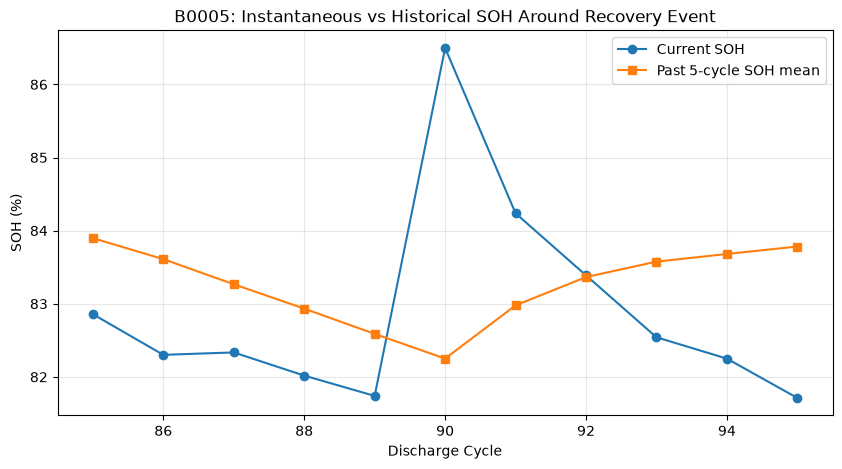

In [6]:
# Compare instantaneous SOH with historical health trajectory

plt.figure(figsize=(10, 5))

plt.plot(
    recovery_window["cycle"],
    recovery_window["SOH_percent"],
    marker="o",
    label="Current SOH"
)

plt.plot(
    recovery_window["cycle"],
    recovery_window["SOH_roll_mean_5"],
    marker="s",
    label="Past 5-cycle SOH mean"
)

plt.xlabel("Discharge Cycle")
plt.ylabel("SOH (%)")
plt.title("B0005: Instantaneous vs Historical SOH Around Recovery Event")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## SOH Prediction — Chronological Holdout

The first predictive task estimates current-cycle SOH from information available through previous discharge cycles.

Current-cycle `SOH_percent` and `capacity_Ah` are excluded from the predictor set because SOH is directly derived from capacity. Historical lagged and rolling health indicators are used instead.

The final 30% of B0005 discharge observations are reserved as a chronological holdout set. No random shuffling is performed.

In [7]:
# ---------------------------------------------------------
# SOH modelling dataset
# ---------------------------------------------------------

soh_features = [
    "SOH_lag1",
    "SOH_roll_mean_5",
    "SOH_roll_std_5",
    "SOH_delta_5",
    "temp_roll_mean_5",
    "temperature_delta_5",
    "voltage_roll_mean_5",
]

soh_target = "SOH_percent"

# Keep only rows with complete causal history
soh_df = (
    b0005_model[
        ["cycle"] + soh_features + [soh_target]
    ]
    .dropna()
    .reset_index(drop=True)
)

# Chronological 70/30 split
split_idx = int(len(soh_df) * 0.70)

soh_train = soh_df.iloc[:split_idx].copy()
soh_test = soh_df.iloc[split_idx:].copy()

X_train_soh = soh_train[soh_features]
y_train_soh = soh_train[soh_target]

X_test_soh = soh_test[soh_features]
y_test_soh = soh_test[soh_target]

# ---------------------------------------------------------
# Validation
# ---------------------------------------------------------

assert len(X_train_soh) == len(y_train_soh)
assert len(X_test_soh) == len(y_test_soh)

assert (
    soh_train["cycle"].max()
    < soh_test["cycle"].min()
)

assert "SOH_percent" not in X_train_soh.columns
assert "capacity_Ah" not in X_train_soh.columns
assert "cycle" not in X_train_soh.columns

print(f"Total modelling observations: {len(soh_df)}")
print(f"Training observations: {len(soh_train)}")
print(f"Testing observations: {len(soh_test)}")

print(
    f"Training cycle range: "
    f"{soh_train['cycle'].min()} to "
    f"{soh_train['cycle'].max()}"
)

print(
    f"Testing cycle range: "
    f"{soh_test['cycle'].min()} to "
    f"{soh_test['cycle'].max()}"
)

print("\nSOH predictors:")
for feature in soh_features:
    print(f"  - {feature}")

Total modelling observations: 162
Training observations: 113
Testing observations: 49
Training cycle range: 7 to 119
Testing cycle range: 120 to 168

SOH predictors:
  - SOH_lag1
  - SOH_roll_mean_5
  - SOH_roll_std_5
  - SOH_delta_5
  - temp_roll_mean_5
  - temperature_delta_5
  - voltage_roll_mean_5


## Baseline SOH Model Comparison

Three regression approaches are evaluated:

1. Linear Regression — interpretable baseline.
2. Ridge Regression — regularized linear model for correlated degradation features.
3. Random Forest — nonlinear ensemble model.

All models are trained on the chronological training period and evaluated only on the later unseen discharge cycles.

In [8]:
# ---------------------------------------------------------
# SOH model training
# ---------------------------------------------------------

soh_linear = LinearRegression()

soh_ridge = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0))
])

soh_rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=8,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

# Fit
soh_linear.fit(X_train_soh, y_train_soh)
soh_ridge.fit(X_train_soh, y_train_soh)
soh_rf.fit(X_train_soh, y_train_soh)

# Predict
pred_soh_linear = soh_linear.predict(X_test_soh)
pred_soh_ridge = soh_ridge.predict(X_test_soh)
pred_soh_rf = soh_rf.predict(X_test_soh)

print("SOH models trained successfully.")

SOH models trained successfully.


In [9]:
def regression_metrics(y_true, y_pred, model_name):
    error = np.asarray(y_pred) - np.asarray(y_true)

    return {
        "Model": model_name,
        "MAE_SOH_pct": mean_absolute_error(y_true, y_pred),
        "RMSE_SOH_pct": np.sqrt(
            mean_squared_error(y_true, y_pred)
        ),
        "R2": r2_score(y_true, y_pred),
        "Bias_SOH_pct": np.mean(error),
    }


soh_results = pd.DataFrame([
    regression_metrics(
        y_test_soh,
        pred_soh_linear,
        "Linear Regression"
    ),
    regression_metrics(
        y_test_soh,
        pred_soh_ridge,
        "Ridge Regression"
    ),
    regression_metrics(
        y_test_soh,
        pred_soh_rf,
        "Random Forest"
    ),
])

soh_results.round(4)

,Model,MAE_SOH_pct,RMSE_SOH_pct,R2,Bias_SOH_pct
0,Linear Regression,0.4843,0.5721,0.9234,0.2437
1,Ridge Regression,0.6045,0.6837,0.8906,0.4053
2,Random Forest,4.0461,4.4604,-3.6576,3.9625


In [10]:
# ---------------------------------------------------------
# SOH prediction results
# ---------------------------------------------------------

soh_predictions = pd.DataFrame({
    "cycle": soh_test["cycle"].to_numpy(),
    "actual_SOH": y_test_soh.to_numpy(),
    "linear_SOH": pred_soh_linear,
    "ridge_SOH": pred_soh_ridge,
    "rf_SOH": pred_soh_rf,
})

soh_predictions["linear_error"] = (
    soh_predictions["linear_SOH"]
    - soh_predictions["actual_SOH"]
)

soh_predictions["ridge_error"] = (
    soh_predictions["ridge_SOH"]
    - soh_predictions["actual_SOH"]
)

soh_predictions["rf_error"] = (
    soh_predictions["rf_SOH"]
    - soh_predictions["actual_SOH"]
)

soh_predictions.head(10).round(3)

,cycle,actual_SOH,linear_SOH,ridge_SOH,rf_SOH,linear_error,ridge_error,rf_error
0,120,77.210,75.633,75.674,76.138,-1.577,-1.536,-1.072
1,121,77.472,76.757,76.697,76.497,-0.715,-0.775,-0.975
2,122,76.346,76.869,76.831,76.566,0.523,0.484,0.220
3,123,75.787,76.021,76.153,76.297,0.234,0.366,0.510
4,124,75.476,75.645,75.850,76.295,0.169,0.374,0.819
5,125,75.234,75.469,75.736,76.361,0.235,0.503,1.128
6,126,74.942,74.974,74.970,76.564,0.032,0.028,1.622
7,127,74.669,74.860,74.807,76.897,0.190,0.138,2.227
8,128,74.357,74.737,74.815,76.852,0.380,0.458,2.494
9,129,74.077,74.475,74.591,76.840,0.397,0.514,2.763


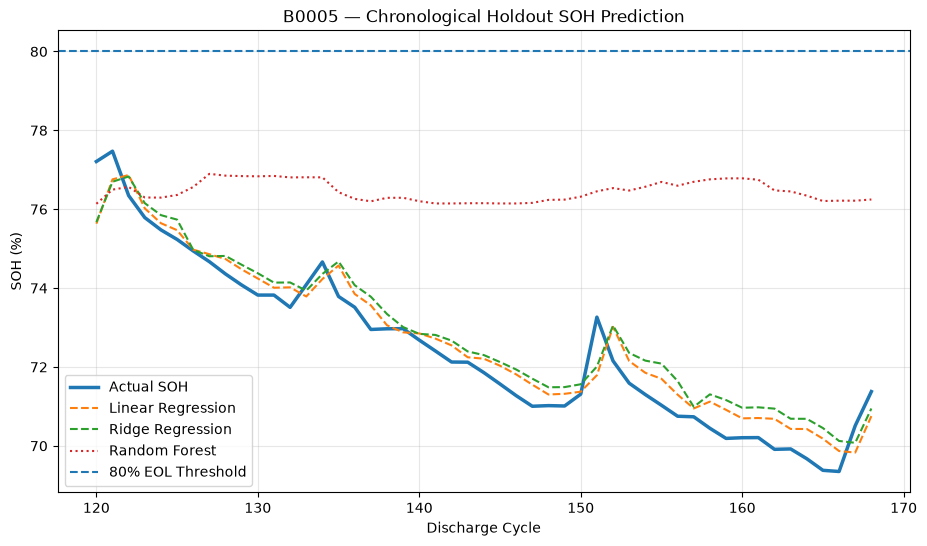

In [11]:
# Actual vs predicted SOH

plt.figure(figsize=(11, 6))

plt.plot(
    soh_predictions["cycle"],
    soh_predictions["actual_SOH"],
    linewidth=2.5,
    label="Actual SOH"
)

plt.plot(
    soh_predictions["cycle"],
    soh_predictions["linear_SOH"],
    linestyle="--",
    label="Linear Regression"
)

plt.plot(
    soh_predictions["cycle"],
    soh_predictions["ridge_SOH"],
    linestyle="--",
    label="Ridge Regression"
)

plt.plot(
    soh_predictions["cycle"],
    soh_predictions["rf_SOH"],
    linestyle=":",
    label="Random Forest"
)

plt.axhline(
    80,
    linestyle="--",
    linewidth=1.5,
    label="80% EOL Threshold"
)

plt.xlabel("Discharge Cycle")
plt.ylabel("SOH (%)")
plt.title(
    "B0005 — Chronological Holdout SOH Prediction"
)

plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [12]:
# ---------------------------------------------------------
# Late-life prediction diagnostics
# ---------------------------------------------------------

print("Last 10 SOH predictions:")
display(
    soh_predictions.tail(10).round(3)
)

print("\nLinear Regression error summary:")

print(
    f"Mean error: "
    f"{soh_predictions['linear_error'].mean():.3f}%"
)

print(
    f"Median error: "
    f"{soh_predictions['linear_error'].median():.3f}%"
)

print(
    f"Minimum error: "
    f"{soh_predictions['linear_error'].min():.3f}%"
)

print(
    f"Maximum error: "
    f"{soh_predictions['linear_error'].max():.3f}%"
)

Last 10 SOH predictions:


,cycle,actual_SOH,linear_SOH,ridge_SOH,rf_SOH,linear_error,ridge_error,rf_error
39,159,70.188,70.913,71.161,76.781,0.725,0.973,6.593
40,160,70.206,70.696,70.966,76.784,0.491,0.760,6.578
41,161,70.208,70.705,70.976,76.748,0.497,0.768,6.540
42,162,69.911,70.685,70.943,76.477,0.774,1.032,6.566
43,163,69.921,70.428,70.687,76.452,0.507,0.766,6.531
44,164,69.673,70.427,70.685,76.344,0.754,1.012,6.672
45,165,69.379,70.181,70.450,76.208,0.803,1.072,6.829
46,166,69.349,69.868,70.123,76.217,0.519,0.774,6.868
47,167,70.510,69.829,70.076,76.217,-0.681,-0.434,5.706
48,168,71.376,70.753,70.946,76.247,-0.622,-0.429,4.871



Linear Regression error summary:
Mean error: 0.244%
Median error: 0.380%
Minimum error: -1.577%
Maximum error: 0.863%


## Remaining Useful Life (RUL) Prediction

RUL is defined relative to the first measured discharge cycle at or below 80% SOH.

For B0005:

- EOL = first discharge cycle where SOH ≤ 80%.
- Pre-EOL observations are used for RUL modelling.
- RUL = EOL discharge cycle − current discharge cycle.
- Current cycle number is excluded from the predictive feature set because it algebraically encodes RUL once EOL is known.
- Current-cycle SOH and capacity are also excluded.
- Only causal historical degradation features are used as predictors.

A chronological holdout is used to evaluate prediction on later unseen pre-EOL degradation states.

In [13]:
# ---------------------------------------------------------
# Determine B0005 EOL
# ---------------------------------------------------------

EOL_THRESHOLD = 80.0

eol_rows = b0005_model.loc[
    b0005_model["SOH_percent"] <= EOL_THRESHOLD
]

if eol_rows.empty:
    raise ValueError(
        "B0005 does not cross the selected EOL threshold."
    )

eol_cycle = int(eol_rows.iloc[0]["cycle"])
eol_soh = float(eol_rows.iloc[0]["SOH_percent"])

print(f"EOL threshold: {EOL_THRESHOLD:.1f}% SOH")
print(f"Observed EOL discharge cycle: {eol_cycle}")
print(f"SOH at EOL observation: {eol_soh:.2f}%")

EOL threshold: 80.0% SOH
Observed EOL discharge cycle: 101
SOH at EOL observation: 79.74%


In [14]:
# ---------------------------------------------------------
# Build causal pre-EOL RUL dataset
# ---------------------------------------------------------

rul_features = [
    "SOH_lag1",
    "SOH_roll_mean_5",
    "SOH_roll_std_5",
    "SOH_delta_5",
    "temp_roll_mean_5",
    "temperature_delta_5",
    "voltage_roll_mean_5",
]

rul_df = b0005_model.loc[
    b0005_model["cycle"] < eol_cycle,
    ["cycle"] + rul_features
].copy()

# True RUL is used ONLY as the target.
rul_df["RUL_cycles"] = (
    eol_cycle - rul_df["cycle"]
)

rul_df = (
    rul_df
    .dropna()
    .reset_index(drop=True)
)

# ---------------------------------------------------------
# Leakage checks
# ---------------------------------------------------------

assert "cycle" not in rul_features
assert "SOH_percent" not in rul_features
assert "capacity_Ah" not in rul_features
assert (rul_df["RUL_cycles"] > 0).all()

print(f"Observed EOL: {eol_cycle}")
print(f"RUL modelling observations: {len(rul_df)}")

print(
    f"Cycle range: "
    f"{rul_df['cycle'].min()} to "
    f"{rul_df['cycle'].max()}"
)

print(
    f"RUL range: "
    f"{rul_df['RUL_cycles'].min()} to "
    f"{rul_df['RUL_cycles'].max()} cycles"
)

print("\nRUL predictors:")
for feature in rul_features:
    print(f"  - {feature}")

Observed EOL: 101
RUL modelling observations: 94
Cycle range: 7 to 100
RUL range: 1 to 94 cycles

RUL predictors:
  - SOH_lag1
  - SOH_roll_mean_5
  - SOH_roll_std_5
  - SOH_delta_5
  - temp_roll_mean_5
  - temperature_delta_5
  - voltage_roll_mean_5


In [15]:
# ---------------------------------------------------------
# Chronological RUL train/test split
# ---------------------------------------------------------

split_idx_rul = int(len(rul_df) * 0.70)

rul_train = rul_df.iloc[:split_idx_rul].copy()
rul_test = rul_df.iloc[split_idx_rul:].copy()

X_train_rul = rul_train[rul_features]
y_train_rul = rul_train["RUL_cycles"]

X_test_rul = rul_test[rul_features]
y_test_rul = rul_test["RUL_cycles"]

# ---------------------------------------------------------
# Validation
# ---------------------------------------------------------

assert len(X_train_rul) == len(y_train_rul)
assert len(X_test_rul) == len(y_test_rul)

assert (
    rul_train["cycle"].max()
    < rul_test["cycle"].min()
)

assert "cycle" not in X_train_rul.columns
assert "SOH_percent" not in X_train_rul.columns
assert "capacity_Ah" not in X_train_rul.columns

print(f"Training observations: {len(rul_train)}")
print(f"Testing observations: {len(rul_test)}")

print(
    f"Training cycle range: "
    f"{rul_train['cycle'].min()} to "
    f"{rul_train['cycle'].max()}"
)

print(
    f"Testing cycle range: "
    f"{rul_test['cycle'].min()} to "
    f"{rul_test['cycle'].max()}"
)

print(
    f"Training RUL range: "
    f"{rul_train['RUL_cycles'].min()} to "
    f"{rul_train['RUL_cycles'].max()}"
)

print(
    f"Testing RUL range: "
    f"{rul_test['RUL_cycles'].min()} to "
    f"{rul_test['RUL_cycles'].max()}"
)

print("\nShapes:")
print("X_train_rul:", X_train_rul.shape)
print("X_test_rul:", X_test_rul.shape)
print("y_train_rul:", y_train_rul.shape)
print("y_test_rul:", y_test_rul.shape)

Training observations: 65
Testing observations: 29
Training cycle range: 7 to 71
Testing cycle range: 72 to 100
Training RUL range: 30 to 94
Testing RUL range: 1 to 29

Shapes:
X_train_rul: (65, 7)
X_test_rul: (29, 7)
y_train_rul: (65,)
y_test_rul: (29,)


## Causal Health-Based RUL Models

Three regression models are evaluated using only causal historical degradation features:

1. Linear Regression
2. Ridge Regression
3. Random Forest

The models do not receive discharge cycle number, current-cycle SOH, or current-cycle capacity as predictors.

Performance is evaluated on the final 29 pre-EOL discharge cycles using MAE, RMSE, R², and signed prediction bias.

In [16]:
# ---------------------------------------------------------
# Train causal RUL models
# ---------------------------------------------------------

rul_linear = LinearRegression()

rul_ridge = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0))
])

rul_rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=8,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

# Fit models
rul_linear.fit(X_train_rul, y_train_rul)
rul_ridge.fit(X_train_rul, y_train_rul)
rul_rf.fit(X_train_rul, y_train_rul)

# Predictions
pred_rul_linear = rul_linear.predict(X_test_rul)
pred_rul_ridge = rul_ridge.predict(X_test_rul)
pred_rul_rf = rul_rf.predict(X_test_rul)

print("RUL models trained successfully.")

RUL models trained successfully.


In [17]:
# ---------------------------------------------------------
# Evaluate RUL models
# ---------------------------------------------------------

def rul_metrics(y_true, y_pred, model_name):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    error = y_pred - y_true

    return {
        "Model": model_name,
        "MAE_cycles": mean_absolute_error(
            y_true, y_pred
        ),
        "RMSE_cycles": np.sqrt(
            mean_squared_error(y_true, y_pred)
        ),
        "R2": r2_score(
            y_true, y_pred
        ),
        "Bias_cycles": np.mean(error),
    }


rul_results = pd.DataFrame([
    rul_metrics(
        y_test_rul,
        pred_rul_linear,
        "Causal Linear Regression"
    ),
    rul_metrics(
        y_test_rul,
        pred_rul_ridge,
        "Causal Ridge Regression"
    ),
    rul_metrics(
        y_test_rul,
        pred_rul_rf,
        "Causal Random Forest"
    ),
])

rul_results.round(4)

,Model,MAE_cycles,RMSE_cycles,R2,Bias_cycles
0,Causal Linear Regression,5.0977,6.6685,0.3647,-4.6711
1,Causal Ridge Regression,4.9341,6.4090,0.4132,-4.4628
2,Causal Random Forest,16.6595,18.6467,-3.9671,16.6595


In [18]:
# ---------------------------------------------------------
# Detailed RUL predictions
# ---------------------------------------------------------

rul_predictions = pd.DataFrame({
    "cycle": rul_test["cycle"].to_numpy(),
    "actual_RUL": y_test_rul.to_numpy(),
    "linear_RUL": pred_rul_linear,
    "ridge_RUL": pred_rul_ridge,
    "rf_RUL": pred_rul_rf,
})

for model in ["linear", "ridge", "rf"]:
    rul_predictions[f"{model}_error"] = (
        rul_predictions[f"{model}_RUL"]
        - rul_predictions["actual_RUL"]
    )

print("Final 10 pre-EOL predictions:")

display(
    rul_predictions.tail(10).round(2)
)

# ---------------------------------------------------------
# Ridge RUL error diagnostics
# ---------------------------------------------------------

ridge_errors = rul_predictions["ridge_error"]

print("Ridge RUL error summary:")
print(f"Mean error:   {ridge_errors.mean():.2f} cycles")
print(f"Median error: {ridge_errors.median():.2f} cycles")
print(f"Minimum error: {ridge_errors.min():.2f} cycles")
print(f"Maximum error: {ridge_errors.max():.2f} cycles")

print("\nLargest absolute Ridge errors:")

largest_ridge_errors = (
    rul_predictions
    .assign(
        absolute_error=lambda x:
        x["ridge_error"].abs()
    )
    .sort_values(
        "absolute_error",
        ascending=False
    )
    .head(10)
)

display(
    largest_ridge_errors[
        [
            "cycle",
            "actual_RUL",
            "ridge_RUL",
            "ridge_error",
            "absolute_error",
        ]
    ].round(2)
)

Final 10 pre-EOL predictions:


,cycle,actual_RUL,linear_RUL,ridge_RUL,rf_RUL,linear_error,ridge_error,rf_error
19,91,10,9.87,8.82,31.70,-0.13,-1.18,21.70
20,92,9,-3.31,-3.13,31.69,-12.31,-12.13,22.69
21,93,8,-6.00,-5.46,31.69,-14.00,-13.46,23.69
22,94,7,-7.82,-6.82,31.70,-14.82,-13.82,24.70
23,95,6,-6.36,-5.10,31.70,-12.36,-11.10,25.70
24,96,5,-7.04,-7.80,31.69,-12.04,-12.80,26.69
25,97,4,-0.30,-0.52,31.69,-4.30,-4.52,27.69
26,98,3,2.56,2.49,31.66,-0.44,-0.51,28.66
27,99,2,3.01,3.11,31.56,1.01,1.11,29.56
28,100,1,-0.34,-0.15,31.67,-1.34,-1.15,30.67


Ridge RUL error summary:
Mean error:   -4.46 cycles
Median error: -3.30 cycles
Minimum error: -13.82 cycles
Maximum error: 4.73 cycles

Largest absolute Ridge errors:


,cycle,actual_RUL,ridge_RUL,ridge_error,absolute_error
22,94,7,-6.82,-13.82,13.82
21,93,8,-5.46,-13.46,13.46
24,96,5,-7.80,-12.80,12.80
20,92,9,-3.13,-12.13,12.13
23,95,6,-5.10,-11.10,11.10
11,83,18,10.12,-7.88,7.88
15,87,14,6.69,-7.31,7.31
10,82,19,12.29,-6.71,6.71
4,76,25,19.38,-5.62,5.62
16,88,13,7.62,-5.38,5.38


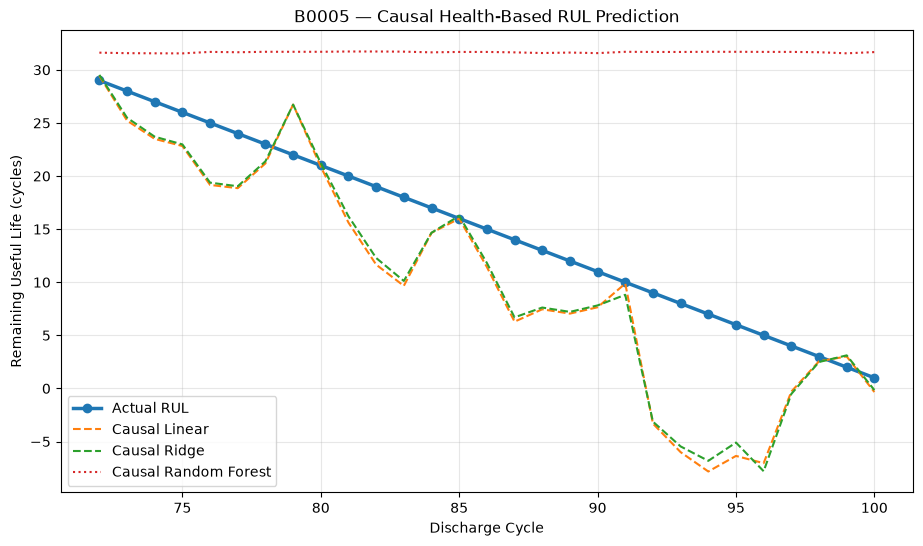

In [19]:
# ---------------------------------------------------------
# Actual vs predicted RUL
# ---------------------------------------------------------

plt.figure(figsize=(11, 6))

plt.plot(
    rul_predictions["cycle"],
    rul_predictions["actual_RUL"],
    linewidth=2.5,
    marker="o",
    label="Actual RUL"
)

plt.plot(
    rul_predictions["cycle"],
    rul_predictions["linear_RUL"],
    linestyle="--",
    label="Causal Linear"
)

plt.plot(
    rul_predictions["cycle"],
    rul_predictions["ridge_RUL"],
    linestyle="--",
    label="Causal Ridge"
)

plt.plot(
    rul_predictions["cycle"],
    rul_predictions["rf_RUL"],
    linestyle=":",
    label="Causal Random Forest"
)

plt.xlabel("Discharge Cycle")
plt.ylabel("Remaining Useful Life (cycles)")
plt.title(
    "B0005 — Causal Health-Based RUL Prediction"
)

plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [20]:
# ---------------------------------------------------------
# Physically constrained RUL predictions
# ---------------------------------------------------------

pred_rul_linear_clipped = np.clip(
    pred_rul_linear,
    0,
    None
)

pred_rul_ridge_clipped = np.clip(
    pred_rul_ridge,
    0,
    None
)

pred_rul_rf_clipped = np.clip(
    pred_rul_rf,
    0,
    None
)

constrained_results = pd.DataFrame([
    rul_metrics(
        y_test_rul,
        pred_rul_linear_clipped,
        "Linear Regression - constrained"
    ),
    rul_metrics(
        y_test_rul,
        pred_rul_ridge_clipped,
        "Ridge Regression - constrained"
    ),
    rul_metrics(
        y_test_rul,
        pred_rul_rf_clipped,
        "Random Forest - constrained"
    ),
])

constrained_results.round(4)

,Model,MAE_cycles,RMSE_cycles,R2,Bias_cycles
0,Linear Regression - constrained,4.0231,4.8299,0.6667,-3.5965
1,Ridge Regression - constrained,3.9350,4.6805,0.6870,-3.4637
2,Random Forest - constrained,16.6595,18.6467,-3.9671,16.6595


In [21]:
# ---------------------------------------------------------
# Physical-boundary diagnostics
# ---------------------------------------------------------

boundary_diagnostics = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Random Forest",
    ],

    "Negative_predictions": [
        np.sum(pred_rul_linear < 0),
        np.sum(pred_rul_ridge < 0),
        np.sum(pred_rul_rf < 0),
    ],

    "Minimum_predicted_RUL": [
        np.min(pred_rul_linear),
        np.min(pred_rul_ridge),
        np.min(pred_rul_rf),
    ],
})

boundary_diagnostics.round(2)

,Model,Negative_predictions,Minimum_predicted_RUL
0,Linear Regression,7,-7.82
1,Ridge Regression,7,-7.80
2,Random Forest,0,31.55


In [22]:
# ---------------------------------------------------------
# Cycle-90 recovery-event diagnostic
# ---------------------------------------------------------

cycles_of_interest = [88, 89, 90, 91, 92]

recovery_rul_check = rul_predictions.loc[
    rul_predictions["cycle"].isin(cycles_of_interest),
    [
        "cycle",
        "actual_RUL",
        "linear_RUL",
        "ridge_RUL",
        "rf_RUL",
        "linear_error",
        "ridge_error",
        "rf_error",
    ],
].copy()

display(
    recovery_rul_check.round(2)
)

,cycle,actual_RUL,linear_RUL,ridge_RUL,rf_RUL,linear_error,ridge_error,rf_error
16,88,13,7.45,7.62,31.58,-5.55,-5.38,18.58
17,89,12,7.05,7.21,31.63,-4.95,-4.79,19.63
18,90,11,7.64,7.82,31.58,-3.36,-3.18,20.58
19,91,10,9.87,8.82,31.70,-0.13,-1.18,21.70
20,92,9,-3.31,-3.13,31.69,-12.31,-12.13,22.69


In [23]:
# ---------------------------------------------------------
# Cycle-90 comparison with Notebook 01
# ---------------------------------------------------------

cycle_90 = rul_predictions.loc[
    rul_predictions["cycle"] == 90
].iloc[0]

print("B0005 discharge cycle 90")
print("--------------------------")

print(
    f"Actual RUL: "
    f"{cycle_90['actual_RUL']:.2f} cycles"
)

print(
    f"Causal Linear prediction: "
    f"{cycle_90['linear_RUL']:.2f} cycles"
)

print(
    f"Causal Linear error: "
    f"{cycle_90['linear_error']:+.2f} cycles"
)

print(
    f"Causal Ridge prediction: "
    f"{cycle_90['ridge_RUL']:.2f} cycles"
)

print(
    f"Causal Ridge error: "
    f"{cycle_90['ridge_error']:+.2f} cycles"
)

print()
print("Notebook 01 instantaneous-health model:")
print("Prediction = 31.28 cycles")
print("Error      = +20.28 cycles")

B0005 discharge cycle 90
--------------------------
Actual RUL: 11.00 cycles
Causal Linear prediction: 7.64 cycles
Causal Linear error: -3.36 cycles
Causal Ridge prediction: 7.82 cycles
Causal Ridge error: -3.18 cycles

Notebook 01 instantaneous-health model:
Prediction = 31.28 cycles
Error      = +20.28 cycles


In [24]:
# ---------------------------------------------------------
# Diagnose late-life feature behaviour
# ---------------------------------------------------------

late_life_features = b0005_model.loc[
    b0005_model["cycle"].between(88, 96),
    [
        "cycle",
        "SOH_percent",
        "SOH_lag1",
        "SOH_roll_mean_5",
        "SOH_roll_std_5",
        "SOH_delta_5",
        "capacity_delta_5",
        "max_temperature_C",
        "temp_roll_mean_5",
        "temperature_delta_5",
        "avg_voltage_V",
        "voltage_roll_mean_5",
    ],
].copy()

display(late_life_features.round(4))

,cycle,SOH_percent,SOH_lag1,SOH_roll_mean_5,SOH_roll_std_5,SOH_delta_5,capacity_delta_5,max_temperature_C,temp_roll_mean_5,temperature_delta_5,avg_voltage_V,voltage_roll_mean_5
87,88,82.0176,82.3343,82.9334,0.6457,-0.3335,-0.0062,40.2472,39.9643,0.0060,3.5110,3.5105
88,89,81.7396,82.0176,82.5882,0.5599,-0.3452,-0.0064,40.3025,39.9851,0.0209,3.5103,3.5098
89,90,86.4977,81.7396,82.2501,0.4163,-0.3381,-0.0063,40.0942,40.0223,0.0372,3.5222,3.5097
90,91,84.2370,86.4977,82.9781,1.9822,0.7281,0.0135,40.5224,40.0662,0.0438,3.5163,3.5119
91,92,83.3882,84.2370,83.3652,2.0059,0.3871,0.0072,40.5689,40.2467,0.1806,3.5134,3.5133
92,93,82.5417,83.3882,83.5760,1.9241,0.2108,0.0039,40.2780,40.3470,0.1003,3.5151,3.5147
93,94,82.2496,82.5417,83.6808,1.8300,0.1048,0.0019,40.2922,40.3532,0.0062,3.5083,3.5155
94,95,81.7112,82.2496,83.7828,1.7047,0.1020,0.0019,40.1844,40.3511,-0.0021,3.5092,3.5151
95,96,81.4386,81.7112,82.8255,0.9954,-0.9573,-0.0178,40.3201,40.3692,0.0180,3.5068,3.5125


In [25]:
# ---------------------------------------------------------
# Ridge feature coefficients
# ---------------------------------------------------------

ridge_model = rul_ridge.named_steps["model"]

ridge_coefficients = pd.DataFrame({
    "Feature": rul_features,
    "Coefficient": ridge_model.coef_,
})

ridge_coefficients["Abs_Coefficient"] = (
    ridge_coefficients["Coefficient"].abs()
)

ridge_coefficients = (
    ridge_coefficients
    .sort_values(
        "Abs_Coefficient",
        ascending=False
    )
    .reset_index(drop=True)
)

display(ridge_coefficients.round(4))

,Feature,Coefficient,Abs_Coefficient
0,SOH_lag1,10.3370,10.3370
1,SOH_roll_mean_5,8.4376,8.4376
2,SOH_roll_std_5,-5.5174,5.5174
3,voltage_roll_mean_5,-4.0328,4.0328
4,SOH_delta_5,2.7280,2.7280
5,temperature_delta_5,-1.1626,1.1626
6,temp_roll_mean_5,0.5145,0.5145


### Recovery-Event Robustness

A major failure case identified in the baseline notebook occurred at B0005 discharge cycle 90, where a transient increase in measured SOH caused the instantaneous-health Linear Regression model to predict 31.28 remaining cycles despite an actual RUL of 11 cycles, producing an error of +20.28 cycles.

Using causal lagged and rolling degradation features substantially reduced sensitivity to this transient recovery event. At the same discharge cycle, the causal Ridge model predicted 7.82 remaining cycles, corresponding to an error of -3.18 cycles.

The absolute prediction error at this event therefore decreased from 20.28 to 3.18 cycles. This result indicates that historical degradation-trajectory features can improve robustness to short-term non-monotonic capacity/SOH behaviour.

However, the causal Ridge model remains imperfect near EOL and can generate physically invalid negative RUL predictions. Therefore, raw and physically constrained model performance are reported separately.

## Cross-Battery Generalization: B0005 → B0006

Single-battery chronological validation evaluates temporal extrapolation within one cell, but it does not establish generalization to another battery.

The next experiment trains the causal RUL model using B0005 and evaluates it on B0006.

For each battery, EOL is independently defined as the first measured discharge cycle at or below 80% SOH. The battery-specific EOL value is used only to construct the ground-truth RUL target for evaluation; it is not supplied as a predictive feature.

The feature engineering procedure remains identical across batteries.

In [26]:
# ---------------------------------------------------------
# Determine B0006 EOL independently
# ---------------------------------------------------------

b0006_eol_rows = b0006_model.loc[
    b0006_model["SOH_percent"] <= EOL_THRESHOLD
]

if b0006_eol_rows.empty:
    raise ValueError(
        "B0006 does not cross the selected EOL threshold."
    )

b0006_eol_cycle = int(
    b0006_eol_rows.iloc[0]["cycle"]
)

b0006_eol_soh = float(
    b0006_eol_rows.iloc[0]["SOH_percent"]
)

print(f"EOL threshold: {EOL_THRESHOLD:.1f}% SOH")
print(
    f"B0006 observed EOL discharge cycle: "
    f"{b0006_eol_cycle}"
)
print(
    f"B0006 SOH at EOL observation: "
    f"{b0006_eol_soh:.2f}%"
)

EOL threshold: 80.0% SOH
B0006 observed EOL discharge cycle: 61
B0006 SOH at EOL observation: 79.05%


In [27]:
# ---------------------------------------------------------
# Build B0006 causal pre-EOL RUL dataset
# ---------------------------------------------------------

b0006_rul_df = b0006_model.loc[
    b0006_model["cycle"] < b0006_eol_cycle,
    ["cycle"] + rul_features
].copy()

b0006_rul_df["RUL_cycles"] = (
    b0006_eol_cycle
    - b0006_rul_df["cycle"]
)

b0006_rul_df = (
    b0006_rul_df
    .dropna()
    .reset_index(drop=True)
)

# ---------------------------------------------------------
# Validation
# ---------------------------------------------------------

assert "cycle" not in rul_features
assert "SOH_percent" not in rul_features
assert "capacity_Ah" not in rul_features

assert (
    b0006_rul_df["RUL_cycles"] > 0
).all()

assert list(
    b0006_rul_df[rul_features].columns
) == list(X_train_rul.columns)

print(
    f"B0006 RUL modelling observations: "
    f"{len(b0006_rul_df)}"
)

print(
    f"B0006 cycle range: "
    f"{b0006_rul_df['cycle'].min()} to "
    f"{b0006_rul_df['cycle'].max()}"
)

print(
    f"B0006 RUL range: "
    f"{b0006_rul_df['RUL_cycles'].min()} to "
    f"{b0006_rul_df['RUL_cycles'].max()} cycles"
)

B0006 RUL modelling observations: 54
B0006 cycle range: 7 to 60
B0006 RUL range: 1 to 54 cycles


### Transfer-Learning Evaluation Protocol

For cross-battery evaluation, all available causal pre-EOL observations from B0005 are used for model training.

B0006 is treated as a completely unseen battery and is used only for external evaluation.

This differs from the within-B0005 chronological experiment, where the final 30% of B0005 observations were withheld for temporal validation.

No B0006 observations are used for model fitting, scaling, hyperparameter selection, or feature construction beyond applying the predefined causal feature-engineering procedure.

In [28]:
# ---------------------------------------------------------
# B0005 -> B0006 cross-battery datasets
# ---------------------------------------------------------

X_train_transfer = rul_df[rul_features].copy()
y_train_transfer = rul_df["RUL_cycles"].copy()

X_test_transfer = b0006_rul_df[rul_features].copy()
y_test_transfer = b0006_rul_df["RUL_cycles"].copy()

# Validation
assert len(X_train_transfer) == 94
assert len(X_test_transfer) == 54

assert list(X_train_transfer.columns) == list(
    X_test_transfer.columns
)

assert "cycle" not in X_train_transfer.columns
assert "SOH_percent" not in X_train_transfer.columns
assert "capacity_Ah" not in X_train_transfer.columns

print("Cross-battery experiment")
print("------------------------")
print(
    f"Training battery: B0005 | "
    f"{len(X_train_transfer)} observations"
)
print(
    f"Testing battery:  B0006 | "
    f"{len(X_test_transfer)} observations"
)

print(
    f"B0005 training RUL range: "
    f"{y_train_transfer.min()} to "
    f"{y_train_transfer.max()} cycles"
)

print(
    f"B0006 testing RUL range: "
    f"{y_test_transfer.min()} to "
    f"{y_test_transfer.max()} cycles"
)

Cross-battery experiment
------------------------
Training battery: B0005 | 94 observations
Testing battery:  B0006 | 54 observations
B0005 training RUL range: 1 to 94 cycles
B0006 testing RUL range: 1 to 54 cycles


In [29]:
# ---------------------------------------------------------
# Train B0005-only transfer models
# ---------------------------------------------------------

transfer_linear = LinearRegression()

transfer_ridge = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0))
])

transfer_rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=8,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

transfer_linear.fit(
    X_train_transfer,
    y_train_transfer
)

transfer_ridge.fit(
    X_train_transfer,
    y_train_transfer
)

transfer_rf.fit(
    X_train_transfer,
    y_train_transfer
)

# Completely unseen B0006 predictions
pred_transfer_linear = transfer_linear.predict(
    X_test_transfer
)

pred_transfer_ridge = transfer_ridge.predict(
    X_test_transfer
)

pred_transfer_rf = transfer_rf.predict(
    X_test_transfer
)

print(
    "B0005 models successfully evaluated "
    "on unseen B0006."
)

B0005 models successfully evaluated on unseen B0006.


In [30]:
# ---------------------------------------------------------
# Raw cross-battery RUL performance
# ---------------------------------------------------------

transfer_results = pd.DataFrame([
    rul_metrics(
        y_test_transfer,
        pred_transfer_linear,
        "Transfer Linear"
    ),
    rul_metrics(
        y_test_transfer,
        pred_transfer_ridge,
        "Transfer Ridge"
    ),
    rul_metrics(
        y_test_transfer,
        pred_transfer_rf,
        "Transfer Random Forest"
    ),
])

display(
    transfer_results.round(4)
)

,Model,MAE_cycles,RMSE_cycles,R2,Bias_cycles
0,Transfer Linear,8.3305,10.0973,0.5803,4.2432
1,Transfer Ridge,6.5443,8.8515,0.6775,3.2688
2,Transfer Random Forest,15.8496,16.8747,-0.1722,15.8496


In [31]:
# ---------------------------------------------------------
# Cross-battery physical-boundary diagnostics
# ---------------------------------------------------------

transfer_boundary = pd.DataFrame({
    "Model": [
        "Transfer Linear",
        "Transfer Ridge",
        "Transfer Random Forest",
    ],

    "Negative_predictions": [
        np.sum(pred_transfer_linear < 0),
        np.sum(pred_transfer_ridge < 0),
        np.sum(pred_transfer_rf < 0),
    ],

    "Minimum_predicted_RUL": [
        np.min(pred_transfer_linear),
        np.min(pred_transfer_ridge),
        np.min(pred_transfer_rf),
    ],

    "Maximum_predicted_RUL": [
        np.max(pred_transfer_linear),
        np.max(pred_transfer_ridge),
        np.max(pred_transfer_rf),
    ],
})

display(
    transfer_boundary.round(2)
)

,Model,Negative_predictions,Minimum_predicted_RUL,Maximum_predicted_RUL
0,Transfer Linear,0,8.52,74.62
1,Transfer Ridge,0,2.46,77.61
2,Transfer Random Forest,0,15.01,72.88


In [32]:
# ---------------------------------------------------------
# B0006 cross-battery prediction diagnostics
# ---------------------------------------------------------

transfer_predictions = pd.DataFrame({
    "cycle": b0006_rul_df["cycle"].to_numpy(),
    "actual_RUL": y_test_transfer.to_numpy(),
    "linear_RUL": pred_transfer_linear,
    "ridge_RUL": pred_transfer_ridge,
    "rf_RUL": pred_transfer_rf,
})

for model in ["linear", "ridge", "rf"]:
    transfer_predictions[f"{model}_error"] = (
        transfer_predictions[f"{model}_RUL"]
        - transfer_predictions["actual_RUL"]
    )

print("Final 15 B0006 pre-EOL predictions:")

display(
    transfer_predictions.tail(15).round(2)
)

Final 15 B0006 pre-EOL predictions:


,cycle,actual_RUL,linear_RUL,ridge_RUL,rf_RUL,linear_error,ridge_error,rf_error
39,46,15,31.11,27.37,30.97,16.11,12.37,15.97
40,47,14,25.95,21.29,30.13,11.95,7.29,16.13
41,48,13,21.69,15.97,29.02,8.69,2.97,16.02
42,49,12,26.20,23.58,32.20,14.20,11.58,20.20
43,50,11,18.11,14.40,33.38,7.11,3.40,22.38
44,51,10,15.64,11.73,33.84,5.64,1.73,23.84
45,52,9,15.13,10.66,31.53,6.13,1.66,22.53
46,53,8,18.10,14.32,25.72,10.10,6.32,17.72
47,54,7,8.52,2.46,31.42,1.52,-4.54,24.42
48,55,6,11.60,4.62,28.72,5.60,-1.38,22.72


In [33]:
# ---------------------------------------------------------
# B0006 Ridge error by RUL regime
# ---------------------------------------------------------

transfer_predictions["RUL_regime"] = pd.cut(
    transfer_predictions["actual_RUL"],
    bins=[0, 10, 20, 30, np.inf],
    labels=[
        "1-10 cycles",
        "11-20 cycles",
        "21-30 cycles",
        ">30 cycles",
    ]
)

ridge_regime_results = (
    transfer_predictions
    .groupby(
        "RUL_regime",
        observed=True
    )
    .agg(
        observations=("actual_RUL", "size"),
        MAE_cycles=(
            "ridge_error",
            lambda x: np.mean(np.abs(x))
        ),
        Bias_cycles=("ridge_error", "mean"),
        Max_abs_error=(
            "ridge_error",
            lambda x: np.max(np.abs(x))
        ),
    )
    .reset_index()
)

display(
    ridge_regime_results.round(2)
)

,RUL_regime,observations,MAE_cycles,Bias_cycles,Max_abs_error
0,1-10 cycles,10,5.03,3.85,10.61
1,11-20 cycles,10,7.52,7.52,18.14
2,21-30 cycles,10,5.01,2.98,15.54
3,>30 cycles,24,7.41,1.38,27.99


In [34]:
# ---------------------------------------------------------
# Largest B0006 Ridge transfer errors
# ---------------------------------------------------------

largest_transfer_errors = (
    transfer_predictions
    .assign(
        absolute_error=lambda x:
        x["ridge_error"].abs()
    )
    .sort_values(
        "absolute_error",
        ascending=False
    )
    .head(10)
)

display(
    largest_transfer_errors[
        [
            "cycle",
            "actual_RUL",
            "ridge_RUL",
            "ridge_error",
            "absolute_error",
        ]
    ].round(2)
)

,cycle,actual_RUL,ridge_RUL,ridge_error,absolute_error
18,25,36,63.99,27.99,27.99
1,8,53,77.61,24.61,24.61
0,7,54,76.71,22.71,22.71
38,45,16,34.14,18.14,18.14
25,32,29,44.54,15.54,15.54
39,46,15,27.37,12.37,12.37
37,44,17,28.67,11.67,11.67
42,49,12,23.58,11.58,11.58
22,29,32,20.82,-11.18,11.18
53,60,1,11.61,10.61,10.61


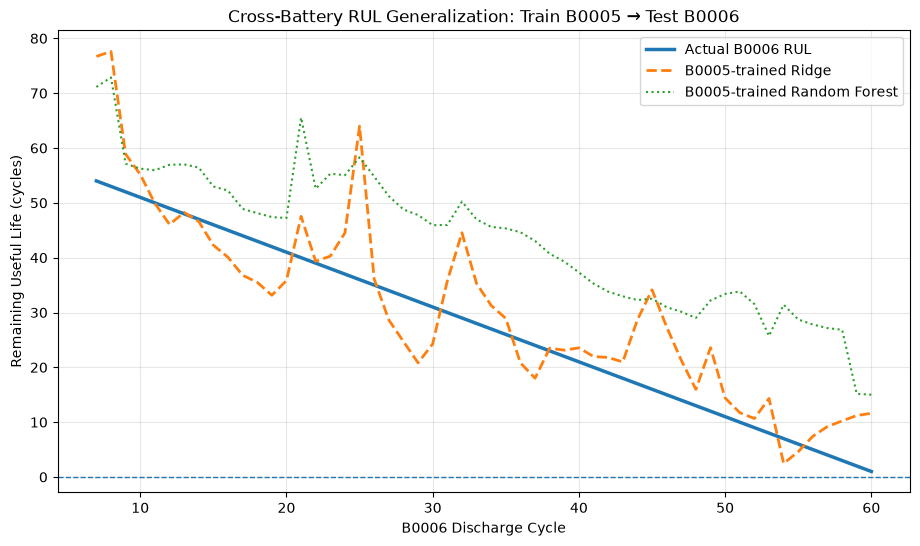

In [35]:
# ---------------------------------------------------------
# B0005 -> B0006 RUL transfer trajectory
# ---------------------------------------------------------

plt.figure(figsize=(11, 6))

plt.plot(
    transfer_predictions["cycle"],
    transfer_predictions["actual_RUL"],
    linewidth=2.5,
    label="Actual B0006 RUL"
)

plt.plot(
    transfer_predictions["cycle"],
    transfer_predictions["ridge_RUL"],
    linestyle="--",
    linewidth=2,
    label="B0005-trained Ridge"
)

plt.plot(
    transfer_predictions["cycle"],
    transfer_predictions["rf_RUL"],
    linestyle=":",
    label="B0005-trained Random Forest"
)

plt.axhline(
    y=0,
    linestyle="--",
    linewidth=1
)

plt.xlabel("B0006 Discharge Cycle")
plt.ylabel("Remaining Useful Life (cycles)")
plt.title(
    "Cross-Battery RUL Generalization: "
    "Train B0005 → Test B0006"
)

plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [36]:
# ---------------------------------------------------------
# Relative RUL error analysis
# ---------------------------------------------------------

transfer_predictions["ridge_abs_error"] = (
    transfer_predictions["ridge_error"].abs()
)

transfer_predictions["ridge_relative_error_pct"] = (
    transfer_predictions["ridge_abs_error"]
    / transfer_predictions["actual_RUL"]
    * 100
)

near_eol = transfer_predictions.loc[
    transfer_predictions["actual_RUL"] <= 10,
    [
        "cycle",
        "actual_RUL",
        "ridge_RUL",
        "ridge_error",
        "ridge_abs_error",
        "ridge_relative_error_pct",
    ]
].copy()

display(near_eol.round(2))

print(
    "Mean relative error in final 10 cycles: "
    f"{near_eol['ridge_relative_error_pct'].mean():.2f}%"
)

print(
    "Median relative error in final 10 cycles: "
    f"{near_eol['ridge_relative_error_pct'].median():.2f}%"
)

,cycle,actual_RUL,ridge_RUL,ridge_error,ridge_abs_error,ridge_relative_error_pct
44,51,10,11.73,1.73,1.73,17.34
45,52,9,10.66,1.66,1.66,18.47
46,53,8,14.32,6.32,6.32,79.04
47,54,7,2.46,-4.54,4.54,64.82
48,55,6,4.62,-1.38,1.38,22.99
49,56,5,7.43,2.43,2.43,48.62
50,57,4,9.20,5.20,5.20,130.07
51,58,3,10.22,7.22,7.22,240.74
52,59,2,11.22,9.22,9.22,460.88
53,60,1,11.61,10.61,10.61,1060.52


Mean relative error in final 10 cycles: 214.35%
Median relative error in final 10 cycles: 71.93%


In [37]:
# ---------------------------------------------------------
# RUL monotonicity diagnostic
# ---------------------------------------------------------

ridge_diff = np.diff(
    transfer_predictions["ridge_RUL"].to_numpy()
)

# RUL should normally decrease as cycle increases.
increases = ridge_diff > 0

print(
    f"Prediction transitions: "
    f"{len(ridge_diff)}"
)

print(
    f"RUL increases instead of decreases: "
    f"{increases.sum()}"
)

print(
    f"Monotonicity violation rate: "
    f"{100 * increases.mean():.2f}%"
)

print(
    f"Largest one-cycle predicted RUL increase: "
    f"{ridge_diff.max():.2f} cycles"
)

print(
    f"Largest one-cycle predicted RUL decrease: "
    f"{ridge_diff.min():.2f} cycles"
)

Prediction transitions: 53
RUL increases instead of decreases: 22
Monotonicity violation rate: 41.51%
Largest one-cycle predicted RUL increase: 19.45 cycles
Largest one-cycle predicted RUL decrease: -27.88 cycles


## Physics-Informed Monotonic RUL Post-Processing

Raw regression predictions may fluctuate from one discharge cycle to the next even though Remaining Useful Life should generally decrease as ageing progresses.

A monotonic post-processing constraint is therefore evaluated. At each observation, the corrected RUL estimate cannot exceed the previous corrected estimate, and negative RUL values are constrained to zero.

This procedure does not use discharge cycle number as a model input and does not alter model training. It is reported separately from raw model performance as a physics-informed post-processing step.

In [38]:
# ---------------------------------------------------------
# Monotonic physical post-processing
# ---------------------------------------------------------

def enforce_monotonic_rul(predictions):
    """
    Enforce:
      1. RUL >= 0
      2. predicted RUL cannot increase with ageing
    """
    predictions = np.asarray(
        predictions,
        dtype=float
    )

    # Physical lower bound
    constrained = np.clip(
        predictions,
        0,
        None
    )

    # Running minimum
    monotonic = np.minimum.accumulate(
        constrained
    )

    return monotonic


pred_transfer_ridge_monotonic = (
    enforce_monotonic_rul(
        pred_transfer_ridge
    )
)

In [39]:
# ---------------------------------------------------------
# Raw vs monotonic Ridge
# ---------------------------------------------------------

ridge_postprocess_results = pd.DataFrame([
    rul_metrics(
        y_test_transfer,
        pred_transfer_ridge,
        "Raw Transfer Ridge"
    ),

    rul_metrics(
        y_test_transfer,
        pred_transfer_ridge_monotonic,
        "Monotonic Transfer Ridge"
    ),
])

display(
    ridge_postprocess_results.round(4)
)

,Model,MAE_cycles,RMSE_cycles,R2,Bias_cycles
0,Raw Transfer Ridge,6.5443,8.8515,0.6775,3.2688
1,Monotonic Transfer Ridge,4.9384,6.6654,0.8171,-1.7569


In [40]:
# ---------------------------------------------------------
# Verify monotonicity
# ---------------------------------------------------------

monotonic_diff = np.diff(
    pred_transfer_ridge_monotonic
)

print(
    "Monotonicity violations after correction:",
    np.sum(monotonic_diff > 0)
)

print(
    "Minimum corrected RUL:",
    pred_transfer_ridge_monotonic.min()
)

print(
    "Maximum corrected RUL:",
    pred_transfer_ridge_monotonic.max()
)

Monotonicity violations after correction: 0
Minimum corrected RUL: 2.4628071668795712
Maximum corrected RUL: 76.70726023599138


In [41]:
# ---------------------------------------------------------
# Near-EOL performance after monotonic correction
# ---------------------------------------------------------

monotonic_predictions = pd.DataFrame({
    "cycle": b0006_rul_df["cycle"].to_numpy(),
    "actual_RUL": y_test_transfer.to_numpy(),
    "raw_ridge_RUL": pred_transfer_ridge,
    "monotonic_ridge_RUL":
        pred_transfer_ridge_monotonic,
})

monotonic_predictions["raw_error"] = (
    monotonic_predictions["raw_ridge_RUL"]
    - monotonic_predictions["actual_RUL"]
)

monotonic_predictions["monotonic_error"] = (
    monotonic_predictions["monotonic_ridge_RUL"]
    - monotonic_predictions["actual_RUL"]
)

near_eol_monotonic = monotonic_predictions.loc[
    monotonic_predictions["actual_RUL"] <= 10
].copy()

display(
    near_eol_monotonic.round(2)
)

print("\nFinal 10-cycle comparison")

print(
    "Raw Ridge MAE:",
    mean_absolute_error(
        near_eol_monotonic["actual_RUL"],
        near_eol_monotonic["raw_ridge_RUL"]
    )
)

print(
    "Monotonic Ridge MAE:",
    mean_absolute_error(
        near_eol_monotonic["actual_RUL"],
        near_eol_monotonic["monotonic_ridge_RUL"]
    )
)

print(
    "Raw Ridge bias:",
    near_eol_monotonic["raw_error"].mean()
)

print(
    "Monotonic Ridge bias:",
    near_eol_monotonic["monotonic_error"].mean()
)

,cycle,actual_RUL,raw_ridge_RUL,monotonic_ridge_RUL,raw_error,monotonic_error
44,51,10,11.73,11.73,1.73,1.73
45,52,9,10.66,10.66,1.66,1.66
46,53,8,14.32,10.66,6.32,2.66
47,54,7,2.46,2.46,-4.54,-4.54
48,55,6,4.62,2.46,-1.38,-3.54
49,56,5,7.43,2.46,2.43,-2.54
50,57,4,9.20,2.46,5.20,-1.54
51,58,3,10.22,2.46,7.22,-0.54
52,59,2,11.22,2.46,9.22,0.46
53,60,1,11.61,2.46,10.61,1.46



Final 10-cycle comparison
Raw Ridge MAE: 5.031484889973322
Monotonic Ridge MAE: 2.067054919525249
Raw Ridge bias: 3.848141740310542
Monotonic Ridge bias: -0.47013791359517965


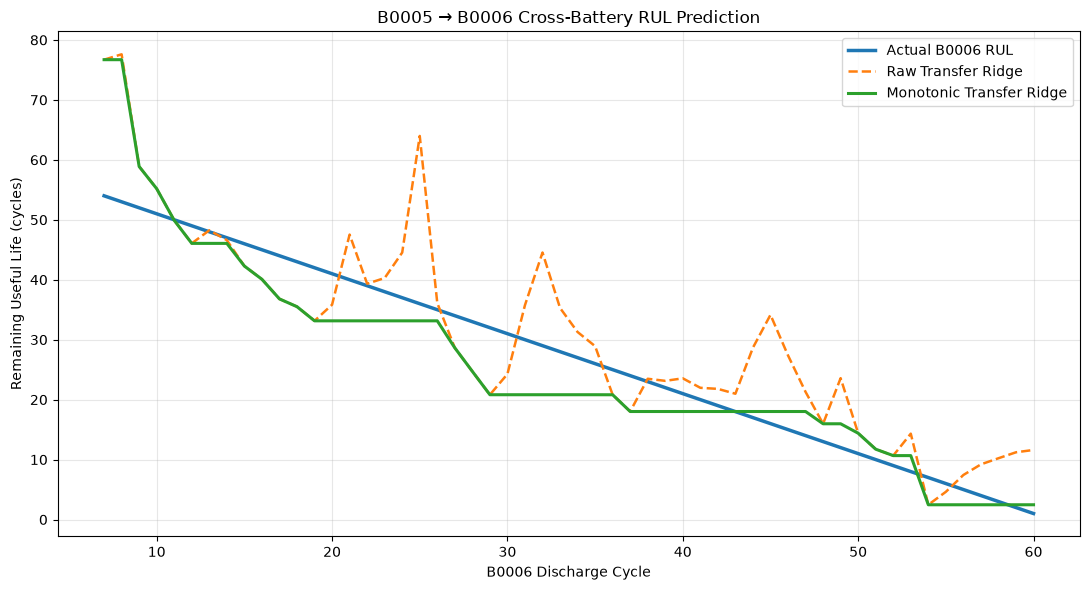

In [42]:
# ---------------------------------------------------------
# Raw vs physics-informed cross-battery RUL trajectory
# ---------------------------------------------------------

plt.figure(figsize=(11, 6))

plt.plot(
    monotonic_predictions["cycle"],
    monotonic_predictions["actual_RUL"],
    linewidth=2.5,
    label="Actual B0006 RUL"
)

plt.plot(
    monotonic_predictions["cycle"],
    monotonic_predictions["raw_ridge_RUL"],
    linestyle="--",
    linewidth=1.8,
    label="Raw Transfer Ridge"
)

plt.plot(
    monotonic_predictions["cycle"],
    monotonic_predictions["monotonic_ridge_RUL"],
    linewidth=2.2,
    label="Monotonic Transfer Ridge"
)

plt.xlabel("B0006 Discharge Cycle")
plt.ylabel("Remaining Useful Life (cycles)")

plt.title(
    "B0005 → B0006 Cross-Battery RUL Prediction"
)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Cross-Battery RUL Results

The B0005-trained Ridge model demonstrated meaningful transfer capability when evaluated on the completely unseen B0006 battery, despite the substantial difference in observed lifetime between the two cells. B0005 reached the 80% SOH threshold at discharge cycle 101, whereas B0006 reached the same threshold at cycle 61.

The raw cross-battery Ridge model achieved:

- MAE: 6.54 cycles
- RMSE: 8.85 cycles
- R²: 0.678
- Mean bias: +3.27 cycles

Analysis of the predicted trajectory showed that 41.51% of consecutive raw RUL predictions increased rather than decreased with battery ageing. The final 10-cycle region also exhibited a mean absolute error of 5.03 cycles and positive bias of +3.85 cycles.

A physics-informed monotonic post-processing constraint was therefore applied, preventing predicted RUL from increasing between successive observations while enforcing non-negative remaining life.

After monotonic post-processing:

- MAE decreased to 4.94 cycles.
- RMSE decreased to 6.67 cycles.
- R² increased to 0.817.
- Mean bias changed to -1.76 cycles.
- Monotonicity violations were eliminated.
- Final-10-cycle MAE decreased from 5.03 to 2.07 cycles.
- Final-10-cycle bias decreased from +3.85 to -0.47 cycles.

These results indicate that causal degradation features learned from B0005 retain useful prognostic information when transferred to an unseen battery with a substantially different degradation lifetime. They also demonstrate that incorporating physically motivated trajectory constraints can materially improve the consistency and near-EOL performance of data-driven RUL predictions.

The monotonic result is reported as post-processed model performance and is not interpreted as the unconstrained Ridge model's intrinsic predictive accuracy.

## Reverse Cross-Battery Generalization: B0006 → B0005

To evaluate whether the observed cross-battery transfer capability is symmetric, the transfer direction is reversed.

All available causal pre-EOL observations from B0006 are used for model training, while B0005 is treated as a completely unseen evaluation battery.

This experiment is particularly challenging because B0006 reaches the 80% SOH threshold at discharge cycle 61, whereas B0005 reaches the same threshold at cycle 101. Consequently, the B0006 training data contain a substantially shorter RUL range than the B0005 evaluation data.

No B0005 observations are used for model fitting or scaling. Battery-specific EOL values are used only to construct the ground-truth RUL targets and are not supplied as predictive features.

In [43]:
# ---------------------------------------------------------
# B0006 -> B0005 reverse-transfer datasets
# ---------------------------------------------------------

X_train_reverse = b0006_rul_df[rul_features].copy()
y_train_reverse = b0006_rul_df["RUL_cycles"].copy()

X_test_reverse = rul_df[rul_features].copy()
y_test_reverse = rul_df["RUL_cycles"].copy()

# Validation
assert len(X_train_reverse) == 54
assert len(X_test_reverse) == 94

assert list(X_train_reverse.columns) == list(
    X_test_reverse.columns
)

assert "cycle" not in X_train_reverse.columns
assert "SOH_percent" not in X_train_reverse.columns
assert "capacity_Ah" not in X_train_reverse.columns

print("Reverse cross-battery experiment")
print("--------------------------------")

print(
    f"Training battery: B0006 | "
    f"{len(X_train_reverse)} observations"
)

print(
    f"Testing battery:  B0005 | "
    f"{len(X_test_reverse)} observations"
)

print(
    f"B0006 training RUL range: "
    f"{y_train_reverse.min()} to "
    f"{y_train_reverse.max()} cycles"
)

print(
    f"B0005 testing RUL range: "
    f"{y_test_reverse.min()} to "
    f"{y_test_reverse.max()} cycles"
)

Reverse cross-battery experiment
--------------------------------
Training battery: B0006 | 54 observations
Testing battery:  B0005 | 94 observations
B0006 training RUL range: 1 to 54 cycles
B0005 testing RUL range: 1 to 94 cycles


In [44]:
# ---------------------------------------------------------
# Train B0006-only reverse-transfer models
# ---------------------------------------------------------

reverse_linear = LinearRegression()

reverse_ridge = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0))
])

reverse_rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=8,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

reverse_linear.fit(
    X_train_reverse,
    y_train_reverse
)

reverse_ridge.fit(
    X_train_reverse,
    y_train_reverse
)

reverse_rf.fit(
    X_train_reverse,
    y_train_reverse
)

pred_reverse_linear = reverse_linear.predict(
    X_test_reverse
)

pred_reverse_ridge = reverse_ridge.predict(
    X_test_reverse
)

pred_reverse_rf = reverse_rf.predict(
    X_test_reverse
)

print(
    "B0006 models successfully evaluated "
    "on unseen B0005."
)

B0006 models successfully evaluated on unseen B0005.


In [45]:
# ---------------------------------------------------------
# Raw B0006 -> B0005 performance
# ---------------------------------------------------------

reverse_results = pd.DataFrame([
    rul_metrics(
        y_test_reverse,
        pred_reverse_linear,
        "Reverse Linear"
    ),

    rul_metrics(
        y_test_reverse,
        pred_reverse_ridge,
        "Reverse Ridge"
    ),

    rul_metrics(
        y_test_reverse,
        pred_reverse_rf,
        "Reverse Random Forest"
    ),
])

display(
    reverse_results.round(4)
)

,Model,MAE_cycles,RMSE_cycles,R2,Bias_cycles
0,Reverse Linear,13.5048,18.7689,0.5215,-12.2117
1,Reverse Ridge,13.3610,18.5024,0.5350,-12.2339
2,Reverse Random Forest,23.3675,28.8155,-0.1278,-23.1792


In [46]:
# ---------------------------------------------------------
# Reverse-transfer boundary diagnostics
# ---------------------------------------------------------

reverse_boundary = pd.DataFrame({
    "Model": [
        "Reverse Linear",
        "Reverse Ridge",
        "Reverse Random Forest",
    ],

    "Negative_predictions": [
        np.sum(pred_reverse_linear < 0),
        np.sum(pred_reverse_ridge < 0),
        np.sum(pred_reverse_rf < 0),
    ],

    "Minimum_predicted_RUL": [
        np.min(pred_reverse_linear),
        np.min(pred_reverse_ridge),
        np.min(pred_reverse_rf),
    ],

    "Maximum_predicted_RUL": [
        np.max(pred_reverse_linear),
        np.max(pred_reverse_ridge),
        np.max(pred_reverse_rf),
    ],
})

display(
    reverse_boundary.round(2)
)

,Model,Negative_predictions,Minimum_predicted_RUL,Maximum_predicted_RUL
0,Reverse Linear,0,9.63,50.67
1,Reverse Ridge,0,8.94,51.41
2,Reverse Random Forest,0,3.97,46.03


### Transfer-Domain Analysis

The B0006-trained model was exposed to RUL targets ranging only from 1 to 54 cycles, whereas the B0005 evaluation dataset extends to 94 cycles of remaining life.

Therefore, reverse-transfer performance is separated into:

1. **In-domain evaluation:** B0005 observations with RUL ≤ 54 cycles, corresponding to the target range represented during B0006 training.
2. **Out-of-domain evaluation:** B0005 observations with RUL > 54 cycles, requiring extrapolation beyond the source battery's observed RUL range.

This distinction helps separate cross-battery health-trajectory transfer from target-range extrapolation failure.

In [47]:
# ---------------------------------------------------------
# Reverse-transfer in-domain vs out-of-domain analysis
# ---------------------------------------------------------

reverse_predictions = pd.DataFrame({
    "cycle": rul_df["cycle"].to_numpy(),
    "actual_RUL": y_test_reverse.to_numpy(),
    "linear_RUL": pred_reverse_linear,
    "ridge_RUL": pred_reverse_ridge,
    "rf_RUL": pred_reverse_rf,
})

reverse_predictions["ridge_error"] = (
    reverse_predictions["ridge_RUL"]
    - reverse_predictions["actual_RUL"]
)

TRAIN_MAX_RUL_REVERSE = y_train_reverse.max()

reverse_predictions["domain"] = np.where(
    reverse_predictions["actual_RUL"]
    <= TRAIN_MAX_RUL_REVERSE,
    "In-domain (RUL <= 54)",
    "Out-of-domain (RUL > 54)"
)

reverse_domain_results = (
    reverse_predictions
    .groupby("domain")
    .agg(
        observations=("actual_RUL", "size"),

        actual_RUL_min=("actual_RUL", "min"),
        actual_RUL_max=("actual_RUL", "max"),

        MAE_cycles=(
            "ridge_error",
            lambda x: np.mean(np.abs(x))
        ),

        RMSE_cycles=(
            "ridge_error",
            lambda x: np.sqrt(np.mean(x ** 2))
        ),

        Bias_cycles=(
            "ridge_error",
            "mean"
        ),

        Max_abs_error=(
            "ridge_error",
            lambda x: np.max(np.abs(x))
        ),
    )
    .reset_index()
)

display(
    reverse_domain_results.round(2)
)

,domain,observations,actual_RUL_min,actual_RUL_max,MAE_cycles,RMSE_cycles,Bias_cycles,Max_abs_error
0,In-domain (RUL <= 54),54,1,54,4.03,4.95,-2.06,13.79
1,Out-of-domain (RUL > 54),40,55,94,25.96,27.77,-25.96,43.25


In [48]:
# ---------------------------------------------------------
# R² by transfer domain
# ---------------------------------------------------------

for domain_name, group in reverse_predictions.groupby(
    "domain"
):
    score = r2_score(
        group["actual_RUL"],
        group["ridge_RUL"]
    )

    print(
        f"{domain_name}: "
        f"R² = {score:.4f}"
    )

In-domain (RUL <= 54): R² = 0.8990
Out-of-domain (RUL > 54): R² = -4.7888


In [49]:
# ---------------------------------------------------------
# Out-of-domain reverse-transfer predictions
# ---------------------------------------------------------

out_of_domain = reverse_predictions.loc[
    reverse_predictions["actual_RUL"]
    > TRAIN_MAX_RUL_REVERSE,
    [
        "cycle",
        "actual_RUL",
        "ridge_RUL",
        "ridge_error",
    ]
].copy()

out_of_domain["absolute_error"] = (
    out_of_domain["ridge_error"].abs()
)

display(
    out_of_domain.head(15).round(2)
)

,cycle,actual_RUL,ridge_RUL,ridge_error,absolute_error
0,7,94,50.75,-43.25,43.25
1,8,93,51.41,-41.59,41.59
2,9,92,50.10,-41.90,41.90
3,10,91,50.01,-40.99,40.99
4,11,90,50.21,-39.79,39.79
5,12,89,50.53,-38.47,38.47
6,13,88,50.36,-37.64,37.64
7,14,87,50.25,-36.75,36.75
8,15,86,50.16,-35.84,35.84
9,16,85,49.21,-35.79,35.79


### Reverse-Transfer Domain Analysis

The B0006 → B0005 transfer experiment revealed a strong dependence on whether the target RUL was represented within the source battery's training domain.

For B0005 observations with RUL ≤ 54 cycles, which lie within the RUL range observed during B0006 training, the Ridge model achieved:

- MAE: 4.03 cycles
- RMSE: 4.95 cycles
- R²: 0.899
- Mean bias: -2.06 cycles

In contrast, for B0005 observations with RUL > 54 cycles, which require extrapolation beyond the maximum RUL represented during B0006 training, performance deteriorated substantially:

- MAE: 25.96 cycles
- RMSE: 27.77 cycles
- R²: -4.789
- Mean bias: -25.96 cycles

The early-life B0005 predictions remained concentrated near approximately 50 cycles even when the actual RUL exceeded 80–90 cycles.

These results indicate that the poor aggregate reverse-transfer performance is dominated by target-range extrapolation rather than uniformly poor cross-battery prediction. Within the source battery's represented RUL domain, the causal Ridge model retains strong predictive capability.

This also demonstrates an important limitation of absolute-cycle RUL modelling: batteries with substantially different degradation lifetimes may associate similar health trajectories with different absolute remaining-cycle counts.

## Normalized-Life Transfer Diagnostic

The preceding experiments showed that absolute-cycle RUL transfer is strongly affected by differences in battery lifetime scale.

To investigate whether degradation state transfers more consistently across cells after removing absolute lifetime differences, a normalized RUL target is evaluated.

For this diagnostic experiment:

RUL fraction = RUL cycles / observed EOL cycle

The resulting target represents remaining life relative to the battery's observed lifetime scale.

Battery-specific EOL information is used only to construct retrospective normalized target labels. Because the eventual EOL cycle of a new battery would not normally be known during deployment, this experiment is treated as a diagnostic analysis of cross-cell degradation similarity rather than a directly deployable RUL estimator.

In [50]:
# ---------------------------------------------------------
# Determine battery-specific EOL cycles
# ---------------------------------------------------------

def get_eol_cycle(df, threshold=80.0):
    """
    Return the first discharge cycle at or below
    the specified SOH threshold.
    """
    eol_rows = df.loc[
        df["SOH_percent"] <= threshold
    ]

    if eol_rows.empty:
        raise ValueError(
            f"Battery does not cross {threshold:.1f}% SOH."
        )

    return int(eol_rows.iloc[0]["cycle"])


b0005_eol_cycle = get_eol_cycle(
    b0005_model,
    EOL_THRESHOLD
)

b0006_eol_cycle = get_eol_cycle(
    b0006_model,
    EOL_THRESHOLD
)

print(
    f"B0005 EOL discharge cycle: {b0005_eol_cycle}"
)

print(
    f"B0006 EOL discharge cycle: {b0006_eol_cycle}"
)

B0005 EOL discharge cycle: 101
B0006 EOL discharge cycle: 61


In [51]:
# ---------------------------------------------------------
# Normalized RUL targets
# ---------------------------------------------------------

b0005_normalized = rul_df.copy()
b0006_normalized = b0006_rul_df.copy()

b0005_normalized["RUL_fraction"] = (
    b0005_normalized["RUL_cycles"]
    / b0005_eol_cycle
)

b0006_normalized["RUL_fraction"] = (
    b0006_normalized["RUL_cycles"]
    / b0006_eol_cycle
)

print("B0005")
print(
    f"EOL cycle: {b0005_eol_cycle} | "
    f"Normalized RUL range: "
    f"{b0005_normalized['RUL_fraction'].min():.4f} "
    f"to {b0005_normalized['RUL_fraction'].max():.4f}"
)

print("\nB0006")
print(
    f"EOL cycle: {b0006_eol_cycle} | "
    f"Normalized RUL range: "
    f"{b0006_normalized['RUL_fraction'].min():.4f} "
    f"to {b0006_normalized['RUL_fraction'].max():.4f}"
)

B0005
EOL cycle: 101 | Normalized RUL range: 0.0099 to 0.9307

B0006
EOL cycle: 61 | Normalized RUL range: 0.0164 to 0.8852


In [52]:
# ---------------------------------------------------------
# B0005 -> B0006 normalized-RUL transfer
# ---------------------------------------------------------

X_norm_5_to_6 = b0005_normalized[rul_features].copy()
y_norm_5_to_6 = b0005_normalized["RUL_fraction"].copy()

X_norm_test_6 = b0006_normalized[rul_features].copy()
y_norm_test_6 = b0006_normalized["RUL_fraction"].copy()

norm_ridge_5_to_6 = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0))
])

norm_ridge_5_to_6.fit(
    X_norm_5_to_6,
    y_norm_5_to_6
)

pred_norm_5_to_6 = norm_ridge_5_to_6.predict(
    X_norm_test_6
)

norm_5_to_6_metrics = {
    "Direction": "B0005 -> B0006",
    "MAE_fraction": mean_absolute_error(
        y_norm_test_6,
        pred_norm_5_to_6
    ),
    "RMSE_fraction": np.sqrt(
        mean_squared_error(
            y_norm_test_6,
            pred_norm_5_to_6
        )
    ),
    "R2": r2_score(
        y_norm_test_6,
        pred_norm_5_to_6
    ),
    "Bias_fraction": np.mean(
        pred_norm_5_to_6 - y_norm_test_6
    ),
}

In [53]:
# ---------------------------------------------------------
# B0006 -> B0005 normalized-RUL transfer
# ---------------------------------------------------------

X_norm_6_to_5 = b0006_normalized[rul_features].copy()
y_norm_6_to_5 = b0006_normalized["RUL_fraction"].copy()

X_norm_test_5 = b0005_normalized[rul_features].copy()
y_norm_test_5 = b0005_normalized["RUL_fraction"].copy()

norm_ridge_6_to_5 = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0))
])

norm_ridge_6_to_5.fit(
    X_norm_6_to_5,
    y_norm_6_to_5
)

pred_norm_6_to_5 = norm_ridge_6_to_5.predict(
    X_norm_test_5
)

norm_6_to_5_metrics = {
    "Direction": "B0006 -> B0005",
    "MAE_fraction": mean_absolute_error(
        y_norm_test_5,
        pred_norm_6_to_5
    ),
    "RMSE_fraction": np.sqrt(
        mean_squared_error(
            y_norm_test_5,
            pred_norm_6_to_5
        )
    ),
    "R2": r2_score(
        y_norm_test_5,
        pred_norm_6_to_5
    ),
    "Bias_fraction": np.mean(
        pred_norm_6_to_5 - y_norm_test_5
    ),
}

In [54]:
# ---------------------------------------------------------
# Reciprocal normalized-transfer results
# ---------------------------------------------------------

normalized_transfer_results = pd.DataFrame([
    norm_5_to_6_metrics,
    norm_6_to_5_metrics,
])

display(
    normalized_transfer_results.round(4)
)

,Direction,MAE_fraction,RMSE_fraction,R2,Bias_fraction
0,B0005 -> B0006,0.1629,0.1997,0.3889,-0.1462
1,B0006 -> B0005,0.1216,0.1342,0.7505,0.1078


In [55]:
# ---------------------------------------------------------
# Normalized-RUL boundary diagnostics
# ---------------------------------------------------------

normalized_boundary = pd.DataFrame({
    "Direction": [
        "B0005 -> B0006",
        "B0006 -> B0005",
    ],

    "Predictions_below_0": [
        np.sum(pred_norm_5_to_6 < 0),
        np.sum(pred_norm_6_to_5 < 0),
    ],

    "Predictions_above_1": [
        np.sum(pred_norm_5_to_6 > 1),
        np.sum(pred_norm_6_to_5 > 1),
    ],

    "Minimum_prediction": [
        np.min(pred_norm_5_to_6),
        np.min(pred_norm_6_to_5),
    ],

    "Maximum_prediction": [
        np.max(pred_norm_5_to_6),
        np.max(pred_norm_6_to_5),
    ],
})

display(
    normalized_boundary.round(4)
)

,Direction,Predictions_below_0,Predictions_above_1,Minimum_prediction,Maximum_prediction
0,B0005 -> B0006,0,0,0.0244,0.7684
1,B0006 -> B0005,0,0,0.1465,0.8428


### Normalized-Life Transfer Results

Normalizing RUL by each battery's observed EOL lifetime produced asymmetric effects on cross-battery transfer.

For B0005 → B0006, normalized-RUL Ridge achieved:

- MAE fraction: 0.163
- RMSE fraction: 0.200
- R²: 0.389
- Mean bias: -0.146

This was weaker than the corresponding absolute-RUL transfer model, which achieved R² = 0.678.

For B0006 → B0005, normalized-RUL Ridge achieved:

- MAE fraction: 0.122
- RMSE fraction: 0.134
- R²: 0.751
- Mean bias: +0.108

This represents a substantial improvement in explained variance compared with the absolute-RUL reverse-transfer model, which achieved R² = 0.535.

No normalized predictions fell outside the physical interval from 0 to 1.

The results therefore partially support the lifetime-scaling hypothesis. Normalization substantially improves transfer from the shorter-lived B0006 battery to the longer-lived B0005 battery, where absolute-cycle modelling previously suffered from severe target-range extrapolation. However, normalization does not universally improve transfer, as performance deteriorated in the B0005 → B0006 direction.

This suggests that cross-cell RUL generalization is influenced by both lifetime-scale differences and battery-specific degradation trajectories.

Because the normalized target is constructed using each battery's eventual observed EOL cycle, this analysis is retrospective and should not be interpreted as a directly deployable RUL prediction method.

In [56]:
# ---------------------------------------------------------
# Final RUL experiment summary
# ---------------------------------------------------------

final_rul_summary = pd.DataFrame([
    {
        "Experiment": "B0005 chronological",
        "Model": "Raw causal Ridge",
        "MAE": 4.9341,
        "RMSE": 6.4090,
        "R2": 0.4132,
        "Bias": -4.4628,
        "Target": "RUL cycles",
    },
    {
        "Experiment": "B0005 chronological",
        "Model": "Non-negative causal Ridge",
        "MAE": 3.9350,
        "RMSE": 4.6805,
        "R2": 0.6870,
        "Bias": -3.4637,
        "Target": "RUL cycles",
    },
    {
        "Experiment": "B0005 -> B0006",
        "Model": "Raw transfer Ridge",
        "MAE": 6.5443,
        "RMSE": 8.8515,
        "R2": 0.6775,
        "Bias": 3.2688,
        "Target": "RUL cycles",
    },
    {
        "Experiment": "B0005 -> B0006",
        "Model": "Monotonic transfer Ridge",
        "MAE": 4.9384,
        "RMSE": 6.6654,
        "R2": 0.8171,
        "Bias": -1.7569,
        "Target": "RUL cycles",
    },
    {
        "Experiment": "B0006 -> B0005",
        "Model": "Raw transfer Ridge",
        "MAE": 13.3610,
        "RMSE": 18.5024,
        "R2": 0.5350,
        "Bias": -12.2339,
        "Target": "RUL cycles",
    },
    {
        "Experiment": "B0006 -> B0005 in-domain",
        "Model": "Raw transfer Ridge",
        "MAE": 4.03,
        "RMSE": 4.95,
        "R2": 0.8990,
        "Bias": -2.06,
        "Target": "RUL cycles",
    },
])

display(final_rul_summary)

,Experiment,Model,MAE,RMSE,R2,Bias,Target
0,B0005 chronological,Raw causal Ridge,4.9341,6.4090,0.4132,-4.4628,RUL cycles
1,B0005 chronological,Non-negative causal Ridge,3.9350,4.6805,0.6870,-3.4637,RUL cycles
2,B0005 -> B0006,Raw transfer Ridge,6.5443,8.8515,0.6775,3.2688,RUL cycles
3,B0005 -> B0006,Monotonic transfer Ridge,4.9384,6.6654,0.8171,-1.7569,RUL cycles
4,B0006 -> B0005,Raw transfer Ridge,13.3610,18.5024,0.5350,-12.2339,RUL cycles
5,B0006 -> B0005 in-domain,Raw transfer Ridge,4.0300,4.9500,0.8990,-2.0600,RUL cycles


In [57]:
# ---------------------------------------------------------
# Normalized-RUL diagnostic summary
# ---------------------------------------------------------

normalized_rul_summary = pd.DataFrame([
    {
        "Direction": "B0005 -> B0006",
        "MAE_fraction": 0.1629,
        "RMSE_fraction": 0.1997,
        "R2": 0.3889,
        "Bias_fraction": -0.1462,
    },
    {
        "Direction": "B0006 -> B0005",
        "MAE_fraction": 0.1216,
        "RMSE_fraction": 0.1342,
        "R2": 0.7505,
        "Bias_fraction": 0.1078,
    },
])

display(normalized_rul_summary)

,Direction,MAE_fraction,RMSE_fraction,R2,Bias_fraction
0,B0005 -> B0006,0.1629,0.1997,0.3889,-0.1462
1,B0006 -> B0005,0.1216,0.1342,0.7505,0.1078


# Conclusions

This notebook developed and evaluated causal machine-learning approaches for battery State of Health (SOH) and Remaining Useful Life (RUL) prediction using the NASA B0005 and B0006 lithium-ion ageing datasets.

## 1. SOH Prediction

Causal SOH models were developed using only information available before the current discharge cycle. Current-cycle SOH, current capacity, and discharge-cycle number were excluded from the predictor set.

For B0005 chronological validation, Linear Regression provided the strongest SOH performance:

- MAE: 0.484 percentage points
- RMSE: 0.572 percentage points
- R²: 0.923
- Mean bias: +0.244 percentage points

Random Forest performed poorly on the late-life holdout, demonstrating the difficulty of tree-based models when extrapolation beyond the training degradation regime is required.

## 2. Causal RUL Prediction

RUL was defined as the number of remaining discharge cycles before the first measured observation at or below 80% SOH.

Discharge-cycle number was deliberately excluded because, once EOL is known, the relationship `RUL = EOL - cycle` would make cycle number an algebraic reconstruction of the target rather than a meaningful prognostic feature.

Using causal lagged and rolling degradation features, Ridge Regression achieved the strongest raw chronological B0005 performance:

- MAE: 4.93 cycles
- RMSE: 6.41 cycles
- R²: 0.413
- Mean bias: -4.46 cycles

Applying a non-negative physical boundary reduced MAE to 3.94 cycles and increased R² to 0.687. This constrained result is reported separately as post-processed performance rather than intrinsic Ridge accuracy.

## 3. Robustness to Transient SOH Recovery

A transient apparent SOH recovery at B0005 discharge cycle 90 produced a major failure in the earlier instantaneous-health baseline.

The baseline Linear Regression model predicted 31.28 remaining cycles against an actual RUL of 11 cycles, producing an error of +20.28 cycles.

The causal Ridge model predicted 7.82 cycles at the same observation, reducing absolute error to 3.18 cycles.

This demonstrates that lagged and rolling degradation-trajectory features can substantially reduce sensitivity to isolated non-monotonic capacity/SOH measurements.

## 4. Cross-Battery Generalization

Cross-battery experiments revealed substantial differences in degradation lifetime:

- B0005 EOL: discharge cycle 101
- B0006 EOL: discharge cycle 61

When trained on all available causal pre-EOL B0005 observations and evaluated on unseen B0006 data, raw Ridge Regression achieved:

- MAE: 6.54 cycles
- RMSE: 8.85 cycles
- R²: 0.678
- Mean bias: +3.27 cycles

However, 41.51% of consecutive raw predictions violated the expected decreasing RUL trajectory.

A physics-informed monotonic post-processing constraint improved performance to:

- MAE: 4.94 cycles
- RMSE: 6.67 cycles
- R²: 0.817
- Mean bias: -1.76 cycles
- Monotonicity violations: 0

In the final 10 cycles before B0006 EOL, MAE decreased from 5.03 to 2.07 cycles and mean bias improved from +3.85 to -0.47 cycles.

The R² = 0.817 result therefore represents the performance of the Ridge model combined with monotonic post-processing, not the unconstrained Ridge model alone.

## 5. Transfer Asymmetry and Extrapolation

Reverse transfer from B0006 to B0005 was substantially more difficult.

Raw Ridge Regression achieved:

- MAE: 13.36 cycles
- RMSE: 18.50 cycles
- R²: 0.535
- Mean bias: -12.23 cycles

The source B0006 battery contained RUL labels only between 1 and 54 cycles, whereas B0005 required predictions extending to 94 cycles.

Separating the evaluation by target domain showed:

**In-domain, RUL ≤ 54 cycles**

- MAE: 4.03 cycles
- RMSE: 4.95 cycles
- R²: 0.899
- Mean bias: -2.06 cycles

**Out-of-domain, RUL > 54 cycles**

- MAE: 25.96 cycles
- RMSE: 27.77 cycles
- R²: -4.789
- Mean bias: -25.96 cycles

This demonstrates that the poor aggregate reverse-transfer result is dominated by target-range extrapolation rather than uniformly poor prediction across B0005.

## 6. Normalized-Life Diagnostic

A retrospective normalized target,

`RUL fraction = RUL cycles / observed EOL cycle`,

was evaluated to investigate whether removing absolute lifetime scale improves cross-cell transfer.

Results were direction-dependent:

- B0005 → B0006: R² = 0.389
- B0006 → B0005: R² = 0.751

Normalization substantially improved the difficult short-life-to-long-life transfer direction but degraded performance in the opposite direction.

Therefore, differences in absolute battery lifetime explain part, but not all, of the cross-cell transfer asymmetry.

Because the normalized target requires knowledge of the battery's eventual observed EOL cycle, this experiment is retrospective and is not presented as a directly deployable RUL estimator.

## Overall Finding

The experiments demonstrate that battery RUL prediction is not simply a regression problem.

Reliable prognostics require careful treatment of:

- temporal causality,
- target leakage,
- degradation-history features,
- non-monotonic capacity measurements,
- physical prediction constraints,
- model extrapolation limits,
- battery-to-battery lifetime variation,
- and near-EOL prediction behaviour.

Among the evaluated approaches, causal Ridge Regression provided the most consistent balance between predictive accuracy, extrapolation capability, interpretability, and cross-battery transfer performance.

Physics-informed monotonic post-processing further improved trajectory consistency and near-EOL performance during B0005 → B0006 transfer.

The results nevertheless represent validation on only two NASA cells and should be interpreted as a controlled prognostic modelling study rather than evidence of broad battery-population generalization.

# Limitations and Future Work

## Limitations

1. **Limited battery population**  
   Cross-battery validation currently uses only NASA B0005 and B0006. Two cells are insufficient to establish population-level generalization.

2. **Battery-specific lifetime variation**  
   B0005 and B0006 reach the 80% SOH threshold at substantially different discharge cycles, demonstrating that absolute-cycle RUL is strongly dependent on cell-specific degradation rate.

3. **EOL threshold definition**  
   EOL is defined as the first measured discharge cycle at or below 80% SOH. Alternative thresholds would change the resulting RUL target.

4. **Capacity/SOH recovery events**  
   Measured capacity is non-monotonic and contains transient recovery behaviour. These observations were retained rather than manually removed because no independent evidence established that they were corrupted measurements.

5. **Limited operating-condition diversity**  
   Results obtained from these NASA ageing experiments should not automatically be generalized to other chemistries, cell formats, duty cycles, temperatures, or field operating conditions.

6. **Post-processing dependence**  
   The strongest B0005 → B0006 RUL result uses monotonic post-processing. This improvement must be distinguished from the underlying raw Ridge model performance.

7. **Normalized-RUL deployment limitation**  
   The normalized-life diagnostic uses the eventual observed EOL cycle to construct retrospective target labels. The true future EOL of an unseen operating battery would not normally be available during deployment.

## Future Work

Future development should include:

- additional NASA cells such as B0007 and B0018;
- leave-one-battery-out cross-validation;
- multi-cell training and independent held-out-cell evaluation;
- uncertainty intervals for RUL predictions;
- asymmetric or safety-aware loss functions that penalize dangerous RUL overprediction;
- monotonic or constrained learning methods incorporated directly into model training;
- degradation-regime detection;
- probabilistic EOL prediction;
- additional electrochemical and time-series features;
- hyperparameter optimization performed without target-battery leakage;
- comparison with sequence models after establishing stronger multi-cell baselines;
- evaluation on independent battery datasets and operating conditions.

# Portfolio Summary

This project implements an end-to-end battery prognostics workflow covering NASA `.mat` data ingestion, discharge-cycle reconstruction, SOH calculation, causal feature engineering, chronological validation, RUL modelling, cross-battery transfer, extrapolation analysis, and physics-informed prediction constraints.

### Key Results

- B0005 SOH prediction: **R² = 0.923**, MAE = **0.484 percentage points**
- B0005 causal RUL Ridge: MAE = **4.93 cycles**
- Physically constrained B0005 RUL: MAE = **3.94 cycles**
- Cycle-90 transient-recovery error reduced from **20.28 to 3.18 cycles**
- B0005 → B0006 raw cross-battery Ridge: **R² = 0.678**
- B0005 → B0006 monotonic Ridge: **R² = 0.817**, MAE = **4.94 cycles**
- Final-10-cycle transfer MAE reduced from **5.03 to 2.07 cycles**
- B0006 → B0005 in-domain transfer: **R² = 0.899**
- Identified severe out-of-domain lifetime extrapolation failure: **R² = -4.789**

The study demonstrates both successful prognostic modelling and the conditions under which apparently strong machine-learning models fail.